In [2]:
from pathlib import Path
import numpy as np
import zarr
import zarr.storage
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Paths ─────────────────────────────────────────────────────────────
ANALYSIS_FILE = Path(
    "/scratch5/purged/Zhanxiang.Hua/credit_wofs_rollout_example/"
    "mae_da_test5/20200416/wofs_20200416_0000_mem01_analysis.zarr.zip"
)

REF_FILE = Path(
    "/scratch5/purged/Zhanxiang.Hua/wofs_preprocess_to_credit_0413/"
    "cases/wofs_20200416_0000_mem01.zarr.zip"
)

PRECIP_VARS = [
    "QRAIN", "QNRAIN", "QHAIL", "QNHAIL",
    "QGRAUP", "QNGRAUPEL", "QSNOW", "QNSNOW"
]

In [3]:
store = zarr.storage.ZipStore(str(ANALYSIS_FILE), mode="r")
root = zarr.open_group(store=store, mode="r")

print("Variables in analysis file:", list(root.keys()))

for v in PRECIP_VARS:
    if v in root:
        print(f"{v}: shape={root[v].shape}, dtype={root[v].dtype}")

Variables in analysis file: ['QNHAIL', 'QNSNOW', 'time', 'QNGRAUPEL', 'norm_output', 'QNRAIN', 'QHAIL', 'QSNOW', 'QRAIN', 'QGRAUP']
QRAIN: shape=(37, 17, 300, 300), dtype=float32
QNRAIN: shape=(37, 17, 300, 300), dtype=float32
QHAIL: shape=(37, 17, 300, 300), dtype=float32
QNHAIL: shape=(37, 17, 300, 300), dtype=float32
QGRAUP: shape=(37, 17, 300, 300), dtype=float32
QNGRAUPEL: shape=(37, 17, 300, 300), dtype=float32
QSNOW: shape=(37, 17, 300, 300), dtype=float32
QNSNOW: shape=(37, 17, 300, 300), dtype=float32


In [4]:
time_vals = root["time"][:]
n_time, n_lev = root["QRAIN"].shape[:2]

ds_analysis = xr.Dataset(
    {v: xr.DataArray(root[v][:], dims=["time","level","y","x"]) for v in PRECIP_VARS if v in root},
    coords={"time": time_vals, "level": np.arange(n_lev)},
)

norm_grp = root["norm_output"]
ds_norm = xr.Dataset(
    {v: xr.DataArray(norm_grp[v][:], dims=["time","level","y","x"]) for v in PRECIP_VARS if v in norm_grp},
    coords={"time": time_vals, "level": np.arange(n_lev)},
)

store.close()

In [5]:
# time_vals = root["time"][:]
# n_time, n_lev = root["QRAIN"].shape[:2]

# ds_analysis = xr.Dataset(
#     {
#         v: xr.DataArray(
#             root[v][:],
#             dims=["time", "level", "y", "x"],
#         )
#         for v in PRECIP_VARS if v in root
#     },
#     coords={
#         "time": time_vals,
#         "level": np.arange(n_lev),
#     },
# )

# store.close()

# print(ds_analysis)

In [6]:
def open_wofs_zarr_zip(filepath, max_attempts: int = 3) -> xr.Dataset:
    """Open a WoFS .zarr.zip file produced by the CREDIT pipeline.

    Replicates the get_forward_data() logic in credit/data.py:
      - builds both zip URI variants (with and without trailing slash in root)
      - tries consolidated=True then consolidated=False
      - retries up to max_attempts times with exponential back-off

    Parameters
    ----------
    filepath : str or Path
        Path to the .zarr.zip file.
    max_attempts : int
        Number of retry attempts per URI.

    Returns
    -------
    xr.Dataset
    """
    zip_file = str(filepath).rstrip("/")
    zip_basename = Path(zip_file).stem  # e.g. "wofs_20200427_1700_mem01"

    # Two URI forms tried by data.py
    uris = [
        f"zip://{zip_basename}::{zip_file}",
        f"zip://{zip_basename}/::{zip_file}",
    ]

    def _try_open(uri: str) -> xr.Dataset:
        last_exc = None
        for consolidated in (True, False):
            try:
                return xr.open_zarr(
                    uri,
                    consolidated=consolidated,
                    zarr_format=2,
                    decode_coords=False,
                    create_default_indexes=False,
                )
            except Exception as exc:
                last_exc = exc
        raise last_exc

    def _try_with_retries(uri: str) -> xr.Dataset:
        last_exc = None
        for attempt in range(1, max_attempts + 1):
            try:
                return _try_open(uri)
            except Exception as exc:
                last_exc = exc
                if attempt < max_attempts:
                    time.sleep(0.25 * attempt)
        raise last_exc

    last_exc = None
    for uri in uris:
        try:
            return _try_with_retries(uri)
        except Exception as exc:
            last_exc = exc

    raise last_exc

In [7]:
ds_ref = open_wofs_zarr_zip(REF_FILE)
print(ds_ref)

<xarray.Dataset> Size: 4GB
Dimensions:                 (time: 37, y: 300, x: 300, level: 17)
Coordinates:
    time                    (time) datetime64[ns] 296B dask.array<chunksize=(37,), meta=np.ndarray>
    y                       (y) int64 2kB dask.array<chunksize=(300,), meta=np.ndarray>
    x                       (x) int64 2kB dask.array<chunksize=(300,), meta=np.ndarray>
    level                   (level) int64 136B dask.array<chunksize=(17,), meta=np.ndarray>
Data variables: (12/43)
    COMPOSITE_REFL_10CM     (time, y, x) float32 13MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    GEOPOT                  (time, level, y, x) float32 226MB dask.array<chunksize=(1, 17, 300, 300), meta=np.ndarray>
    HGT                     (time, y, x) float32 13MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    LWP                     (time, y, x) float32 13MB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    Q2                      (time, y, x) float32 13MB dask.arr

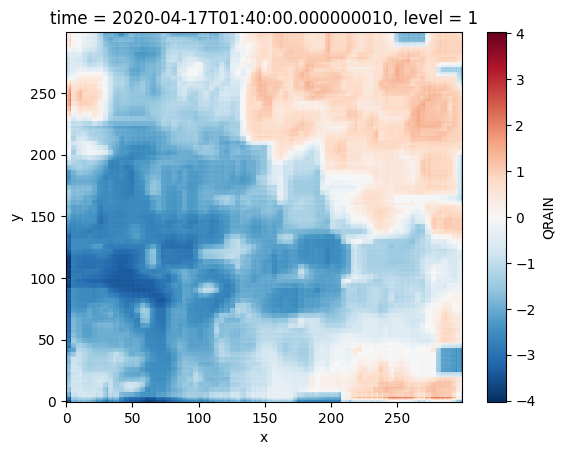

In [11]:
ds_norm["QRAIN"].isel(time=10, level=1).plot()

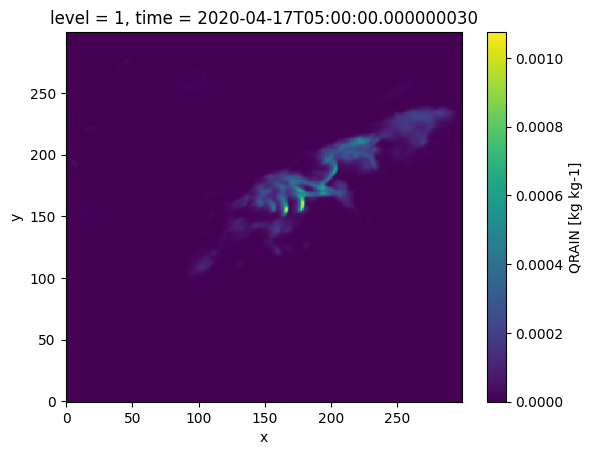

In [13]:
ds_ref["QRAIN"].isel(time=30, level=1).plot()

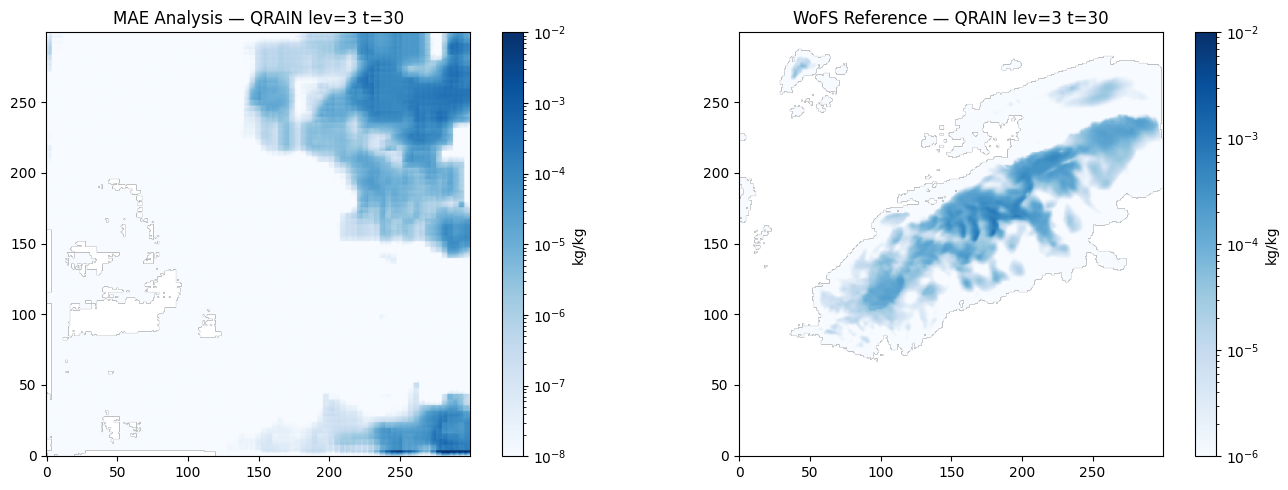

In [9]:
T_IDX = 30
LEVEL = 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Analysis ─────────────────────────────────────────────
qrain_analysis = ds_analysis["QRAIN"].isel(time=T_IDX, level=LEVEL).values

im0 = axes[0].imshow(
    qrain_analysis,
    origin="lower",
    cmap="Blues",
    norm=mcolors.LogNorm(vmin=1e-8, vmax=1e-2),
)

axes[0].set_title(f"MAE Analysis — QRAIN lev={LEVEL} t={T_IDX}")
plt.colorbar(im0, ax=axes[0], label="kg/kg")

# ── Reference ─────────────────────────────────────────────
if "QRAIN" in ds_ref:
    qrain_ref = ds_ref["QRAIN"].isel(time=T_IDX).values

    if qrain_ref.ndim == 3:
        qrain_ref = qrain_ref[LEVEL]

    im1 = axes[1].imshow(
        qrain_ref[:300, :300],
        origin="lower",
        cmap="Blues",
        norm=mcolors.LogNorm(vmin=1e-6, vmax=1e-2),
    )

    axes[1].set_title(f"WoFS Reference — QRAIN lev={LEVEL} t={T_IDX}")
    plt.colorbar(im1, ax=axes[1], label="kg/kg")
else:
    axes[1].set_title("Reference QRAIN not found")

plt.tight_layout()
plt.show()

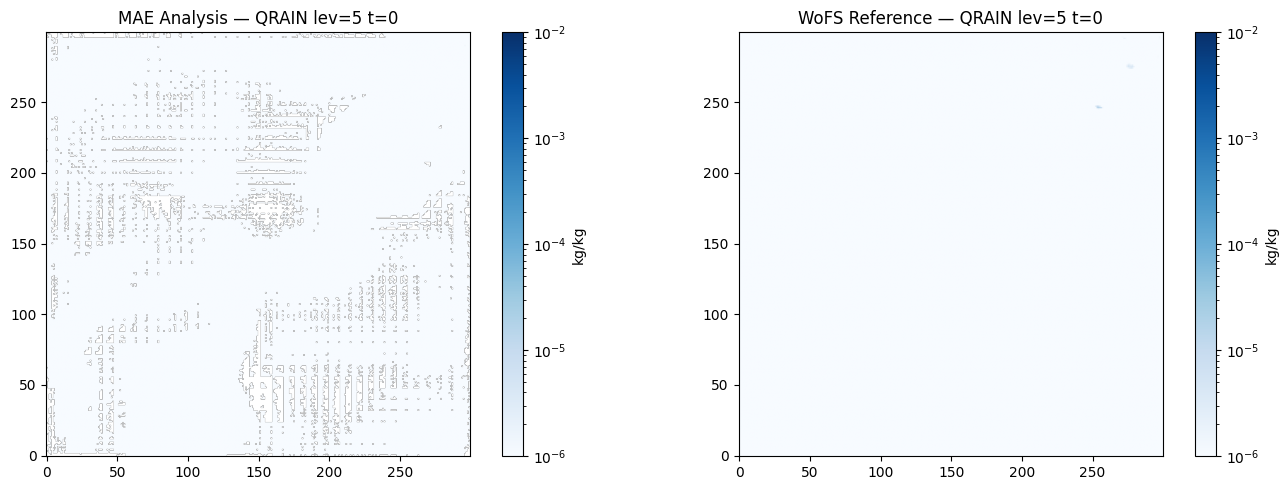

In [15]:
T_IDX = 0
LEVEL = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Analysis ─────────────────────────────────────────────
qrain_analysis = ds_analysis["QRAIN"].isel(time=T_IDX, level=LEVEL).values

im0 = axes[0].imshow(
    qrain_analysis,
    origin="lower",
    cmap="Blues",
    norm=mcolors.LogNorm(vmin=1e-6, vmax=1e-2),
)

axes[0].set_title(f"MAE Analysis — QRAIN lev={LEVEL} t={T_IDX}")
plt.colorbar(im0, ax=axes[0], label="kg/kg")

# ── Reference ─────────────────────────────────────────────
if "QRAIN" in ds_ref:
    qrain_ref = ds_ref["QRAIN"].isel(time=T_IDX).values

    if qrain_ref.ndim == 3:
        qrain_ref = qrain_ref[LEVEL]

    im1 = axes[1].imshow(
        qrain_ref[:300, :300],
        origin="lower",
        cmap="Blues",
        norm=mcolors.LogNorm(vmin=1e-6, vmax=1e-2),
    )

    axes[1].set_title(f"WoFS Reference — QRAIN lev={LEVEL} t={T_IDX}")
    plt.colorbar(im1, ax=axes[1], label="kg/kg")
else:
    axes[1].set_title("Reference QRAIN not found")

plt.tight_layout()
plt.show()

In [16]:
if "QRAIN" in ds_ref:
    print(f"{'Variable':<12} {'Mean RMSE (all levels)'}")

    for v in PRECIP_VARS:
        if v not in ds_analysis or v not in ds_ref:
            continue

        ana = ds_analysis[v].values[:, :, :300, :300]  # crop spatial domain
        ref = ds_ref[v].values

        # Ensure 4D shape
        if ref.ndim == 3:
            ref = ref[:, np.newaxis, ...]

        min_t = min(ana.shape[0], ref.shape[0])

        rmse = np.sqrt(
            np.mean((ana[:min_t] - ref[:min_t]) ** 2)
        )

        print(f"{v:<12} {rmse:.4e}")

Variable     Mean RMSE (all levels)


/tmp/ipykernel_3487179/4065568584.py:18: RuntimeWarning: overflow encountered in square
  np.mean((ana[:min_t] - ref[:min_t]) ** 2)


QRAIN        inf


/scratch3/NAGAPE/gpu-ai4wp/Zhanxiang.Hua/envs/credit-wofs/lib/python3.11/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


QNRAIN       inf
QHAIL        inf
QNHAIL       inf
QGRAUP       inf
QNGRAUPEL    inf
QSNOW        inf
QNSNOW       inf
